# Model 2 — Character Detector inside Iranian Plate Crops

This notebook trains the second model in the ALPR pipeline.

Input:
- Cropped plate images from `Datasets/DS_model_2/train`
- Cropped plate images from `Datasets/DS_model_2/valid`

Annotation:
- Side-by-side XML files with the same stem as each image
- Pascal/VOC-like compact XML
- XML may not contain `<size>`, `<width>`, or `<height>`
- Image dimensions are always read from image files

Training target:
- One-class YOLO detector
- Class `0`: character

Strict rule:
- Each valid plate crop must contain exactly 8 usable character boxes.
- Objects named `کل ناحیه پلاک` are ignored and never used as character boxes.

## Safety Contract

This notebook is intentionally strict:

- No train/valid mixing.
- No test split creation.
- No physical deletion of invalid samples.
- Invalid image/XML pairs are logged.
- XML image size is not trusted.
- Image dimensions are read from the actual image file.
- All bounding boxes are validated.
- Boxes are clamped only for tiny overflow and logged.
- Samples with malformed boxes are invalid.
- Samples with non-exactly-8 usable character boxes are invalid.
- Character order is preserved left-to-right by bbox center x.
- Generated YOLO labels use normalized coordinates from original image dimensions.

In [1]:
from __future__ import annotations

import os
import re
import json
import math
import time
import random
import shutil
import platform
import warnings
import xml.etree.ElementTree as ET
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd

from PIL import Image, ImageDraw, ImageFont, ImageFile, UnidentifiedImageError

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch

ImageFile.LOAD_TRUNCATED_IMAGES = False

warnings.filterwarnings("default")

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("Platform:", platform.platform())

Python: 3.10.19
PyTorch: 2.12.0
Platform: macOS-26.5.1-arm64-arm-64bit


In [2]:
try:
    from ultralytics import YOLO
    import ultralytics
    print("Ultralytics version:", ultralytics.__version__)
except Exception as exc:
    YOLO = None
    print("[ERROR] Could not import ultralytics.")
    print("Install it with:")
    print("    pip install ultralytics")
    raise exc

Ultralytics version: 8.4.70


In [3]:
@dataclass(frozen=True)
class Model2Config:
    # Project paths
    project_root: Path = Path(".").resolve()
    dataset_root: Path = Path("Datasets/DS_model_2")
    train_dir_name: str = "train"
    valid_dir_name: str = "valid"

    yolo_models_dir: Path = Path("yolo models")
    base_yolo_model_name: str = "yolo26l.pt"

    saved_model_dir: Path = Path("Saved_models/model_2_fixed")

    # XML/object rules
    ignored_plate_label: str = "کل ناحیه پلاک"
    yolo_class_id: int = 0
    yolo_class_name: str = "character"
    required_character_count: int = 8

    # Image handling
    valid_image_extensions: Tuple[str, ...] = (
        ".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"
    )
    ignore_hidden_files: bool = True

    # Invalid sample blacklist
    use_existing_invalid_report_as_blacklist: bool = True
    blacklist_match_by_stem: bool = True

    # BBox validation
    tiny_overflow_px: int = 1
    reject_if_box_outside_more_than_tiny: bool = True
    min_box_width_px: int = 2
    min_box_height_px: int = 2

    # Extra strict quality checks
    reject_duplicate_or_near_duplicate_boxes: bool = True
    duplicate_iou_threshold: float = 0.90
    reject_extreme_box_size_outliers: bool = True
    min_box_area_ratio: float = 0.0005
    max_box_area_ratio: float = 0.35

    # YOLO generated dataset
    generated_dataset_dir_name: str = "yolo_dataset"
    generated_images_dir_name: str = "images"
    generated_labels_dir_name: str = "labels"

    # Training
    seed: int = 20260531
    epochs: int = 250
    imgsz: int = 608
    batch: int = 12
    patience: int = 60
    workers: int = 0

    optimizer: str = "AdamW"
    lr0: float = 3e-4
    lrf: float = 0.05
    weight_decay: float = 0.001
    warmup_epochs: float = 5.0
    warmup_momentum: float = 0.8
    warmup_bias_lr: float = 3e-4
    cos_lr: bool = True

    # Loss balance: one-class detector, localization is more important than class loss.
    box: float = 10.0
    cls: float = 0.20
    dfl: float = 2.0

    close_mosaic: int = 0

    # Conservative augmentations for cropped plates.
    hsv_h: float = 0.005
    hsv_s: float = 0.15
    hsv_v: float = 0.15
    degrees: float = 0.0
    translate: float = 0.0
    scale: float = 0.0
    shear: float = 0.0
    perspective: float = 0.0
    flipud: float = 0.0
    fliplr: float = 0.0
    mosaic: float = 0.0
    mixup: float = 0.0
    copy_paste: float = 0.0
    erasing: float = 0.0

    # Validation / inference
    validation_conf: float = 0.001
    inference_conf: float = 0.25
    inference_iou: float = 0.50
    max_det: int = 20
    crop_padding_px: int = 2

    # Device
    prefer_mps: bool = True
    allow_cpu_fallback: bool = True
    allow_yolo_cpu_fallback: bool = False

    # Output files
    config_name: str = "config.json"
    data_yaml_name: str = "data.yaml"
    valid_index_name: str = "valid_samples.csv"
    invalid_report_name: str = "invalid_samples.csv"
    bbox_clamp_report_name: str = "bbox_clamp_report.csv"
    conversion_log_name: str = "conversion_log.csv"
    blacklist_report_name: str = "blacklisted_samples.csv"

    # Visualization
    preview_count: int = 8


CFG = Model2Config()

PROJECT_ROOT = CFG.project_root
DATASET_ROOT = PROJECT_ROOT / CFG.dataset_root
TRAIN_DIR = DATASET_ROOT / CFG.train_dir_name
VALID_DIR = DATASET_ROOT / CFG.valid_dir_name

YOLO_MODELS_DIR = PROJECT_ROOT / CFG.yolo_models_dir
BASE_YOLO_MODEL_PATH = YOLO_MODELS_DIR / CFG.base_yolo_model_name

SAVED_DIR = PROJECT_ROOT / CFG.saved_model_dir
GENERATED_DATASET_DIR = SAVED_DIR / CFG.generated_dataset_dir_name

YOLO_IMAGES_TRAIN_DIR = GENERATED_DATASET_DIR / CFG.generated_images_dir_name / "train"
YOLO_IMAGES_VALID_DIR = GENERATED_DATASET_DIR / CFG.generated_images_dir_name / "valid"

YOLO_LABELS_TRAIN_DIR = GENERATED_DATASET_DIR / CFG.generated_labels_dir_name / "train"
YOLO_LABELS_VALID_DIR = GENERATED_DATASET_DIR / CFG.generated_labels_dir_name / "valid"

DATA_YAML_PATH = SAVED_DIR / CFG.data_yaml_name

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_ROOT:", DATASET_ROOT)
print("TRAIN_DIR:", TRAIN_DIR)
print("VALID_DIR:", VALID_DIR)
print("BASE_YOLO_MODEL_PATH:", BASE_YOLO_MODEL_PATH)
print("SAVED_DIR:", SAVED_DIR)
print("GENERATED_DATASET_DIR:", GENERATED_DATASET_DIR)

PROJECT_ROOT: /Users/sam/Desktop/aiolearn/My_projects/CLPR
DATASET_ROOT: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Datasets/DS_model_2
TRAIN_DIR: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Datasets/DS_model_2/train
VALID_DIR: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Datasets/DS_model_2/valid
BASE_YOLO_MODEL_PATH: /Users/sam/Desktop/aiolearn/My_projects/CLPR/yolo models/yolo26l.pt
SAVED_DIR: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved_models/model_2_fixed
GENERATED_DATASET_DIR: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved_models/model_2_fixed/yolo_dataset


In [4]:
def seed_everything(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception as exc:
        print(f"[WARN] Could not enable deterministic algorithms: {exc}")


seed_everything(CFG.seed)


def get_torch_device(prefer_mps: bool = True, allow_cpu_fallback: bool = True) -> torch.device:
    if prefer_mps and torch.backends.mps.is_available():
        print("[DEVICE] Using Apple MPS for torch operations.")
        return torch.device("mps")

    if prefer_mps and not torch.backends.mps.is_available():
        msg = "[DEVICE] Apple MPS is not available."
        if allow_cpu_fallback:
            print(msg + " Falling back to CPU.")
            return torch.device("cpu")
        raise RuntimeError(msg + " CPU fallback is disabled.")

    print("[DEVICE] Using CPU by configuration.")
    return torch.device("cpu")


DEVICE = get_torch_device(CFG.prefer_mps, CFG.allow_cpu_fallback)


def get_yolo_device_string(cfg: Model2Config) -> str:
    """
    Ultralytics accepts device strings such as:
    - 'cpu'
    - 'mps'
    - '0' for CUDA GPU

    We do not use CUDA-specific code.
    """
    if cfg.prefer_mps and torch.backends.mps.is_available():
        return "mps"

    if cfg.allow_yolo_cpu_fallback:
        print("[YOLO DEVICE WARN] MPS unavailable or disabled. YOLO will use CPU.")
        return "cpu"

    raise RuntimeError(
        "YOLO MPS device is not available and allow_yolo_cpu_fallback=False. "
        "Enable CPU fallback explicitly only if you accept slower training."
    )


YOLO_DEVICE = get_yolo_device_string(CFG)

print("Torch device:", DEVICE)
print("YOLO device:", YOLO_DEVICE)
print("MPS available:", torch.backends.mps.is_available())
print("MPS built:", torch.backends.mps.is_built())

[DEVICE] Using Apple MPS for torch operations.
Torch device: mps
YOLO device: mps
MPS available: True
MPS built: True


In [5]:
def require_dir(path: Path, description: str) -> None:
    if not path.exists():
        raise FileNotFoundError(f"{description} does not exist: {path}")
    if not path.is_dir():
        raise NotADirectoryError(f"{description} is not a directory: {path}")


def require_file(path: Path, description: str) -> None:
    if not path.exists():
        raise FileNotFoundError(f"{description} does not exist: {path}")
    if not path.is_file():
        raise FileNotFoundError(f"{description} is not a file: {path}")


require_dir(DATASET_ROOT, "Model 2 dataset root")
require_dir(TRAIN_DIR, "Model 2 train directory")
require_dir(VALID_DIR, "Model 2 valid directory")
require_dir(YOLO_MODELS_DIR, "YOLO models directory")
require_file(BASE_YOLO_MODEL_PATH, "Base YOLO model")

SAVED_DIR.mkdir(parents=True, exist_ok=True)
(SAVED_DIR / "plots").mkdir(parents=True, exist_ok=True)
(SAVED_DIR / "preview_annotations").mkdir(parents=True, exist_ok=True)
(SAVED_DIR / "inference_examples").mkdir(parents=True, exist_ok=True)

print("[OK] Required paths validated.")

[OK] Required paths validated.


In [6]:
def print_boxed(title: str) -> None:
    line = "=" * max(80, len(title) + 8)
    print("\n" + line)
    print(title)
    print(line)


def is_hidden_path(path: Path) -> bool:
    return any(part.startswith(".") for part in path.parts)


def is_supported_image(path: Path, extensions: Tuple[str, ...]) -> bool:
    return path.suffix.lower() in extensions


def safe_json_dump(obj: Any, path: Path) -> None:
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


def pil_get_image_size(path: Path) -> Tuple[int, int]:
    try:
        with Image.open(path) as img:
            img.verify()

        with Image.open(path) as img:
            img = img.convert("RGB")
            width, height = img.size

        if width <= 0 or height <= 0:
            raise ValueError(f"Invalid non-positive image size: {(width, height)}")

        return width, height

    except Exception as exc:
        raise RuntimeError(f"Could not read image dimensions from {path}: {exc}") from exc


def load_rgb_image(path: Path) -> Image.Image:
    with Image.open(path) as img:
        return img.convert("RGB")


def normalize_label_text(text: Optional[str]) -> str:
    if text is None:
        return ""
    return text.strip()


def ensure_clean_dir(path: Path) -> None:
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

In [7]:
@dataclass
class RawObjectBox:
    name: str
    xmin: float
    ymin: float
    xmax: float
    ymax: float


@dataclass
class ValidCharacterBox:
    name: str
    xmin: int
    ymin: int
    xmax: int
    ymax: int
    center_x: float
    center_y: float
    width: int
    height: int
    original_order: int


@dataclass
class ValidSample:
    split: str
    image_path: Path
    xml_path: Path
    width: int
    height: int
    boxes_left_to_right: List[ValidCharacterBox]


@dataclass
class InvalidSample:
    split: str
    image_path: Optional[str]
    xml_path: Optional[str]
    reason: str
    detail: str


@dataclass
class ClampEvent:
    split: str
    image_path: str
    xml_path: str
    object_name: str
    before: Tuple[float, float, float, float]
    after: Tuple[int, int, int, int]
    reason: str

In [8]:
def parse_pascal_voc_xml(xml_path: Path) -> List[RawObjectBox]:
    """
    Parse Pascal/VOC-like XML.

    Important:
    - We do not rely on XML <size>.
    - XML may be compact single-line.
    - Only object/name and bndbox xmin/ymin/xmax/ymax are needed.
    """
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
    except Exception as exc:
        raise RuntimeError(f"Failed to parse XML {xml_path}: {exc}") from exc

    objects: List[RawObjectBox] = []

    for obj in root.findall(".//object"):
        name = normalize_label_text(obj.findtext("name"))

        bndbox = obj.find("bndbox")
        if bndbox is None:
            raise ValueError(f"Object without bndbox in {xml_path}")

        def read_coord(tag: str) -> float:
            value = bndbox.findtext(tag)
            if value is None:
                raise ValueError(f"Missing {tag} in bndbox in {xml_path}")
            value = value.strip()
            if value == "":
                raise ValueError(f"Empty {tag} in bndbox in {xml_path}")
            return float(value)

        xmin = read_coord("xmin")
        ymin = read_coord("ymin")
        xmax = read_coord("xmax")
        ymax = read_coord("ymax")

        objects.append(
            RawObjectBox(
                name=name,
                xmin=xmin,
                ymin=ymin,
                xmax=xmax,
                ymax=ymax,
            )
        )

    return objects

In [9]:
def validate_and_maybe_clamp_box(
    raw: RawObjectBox,
    image_width: int,
    image_height: int,
    cfg: Model2Config,
) -> Tuple[Optional[Tuple[int, int, int, int]], Optional[str], Optional[str]]:
    """
    Returns:
        bbox or None,
        rejection_reason or None,
        clamp_reason or None
    """
    values = [raw.xmin, raw.ymin, raw.xmax, raw.ymax]

    if any(not np.isfinite(v) for v in values):
        return None, "Non-finite bbox coordinate", None

    xmin, ymin, xmax, ymax = values

    if xmax <= xmin or ymax <= ymin:
        return None, f"Non-positive bbox area before clamp: {(xmin, ymin, xmax, ymax)}", None

    overflow_left = max(0.0, -xmin)
    overflow_top = max(0.0, -ymin)
    overflow_right = max(0.0, xmax - image_width)
    overflow_bottom = max(0.0, ymax - image_height)
    max_overflow = max(overflow_left, overflow_top, overflow_right, overflow_bottom)

    clamp_reason = None

    if max_overflow > 0:
        if max_overflow <= cfg.tiny_overflow_px:
            clamp_reason = f"Tiny overflow clamped: max_overflow={max_overflow:.3f}px"
        else:
            if cfg.reject_if_box_outside_more_than_tiny:
                return None, (
                    f"BBox outside image by more than tiny threshold. "
                    f"bbox={(xmin, ymin, xmax, ymax)}, "
                    f"image_size={(image_width, image_height)}, "
                    f"max_overflow={max_overflow:.3f}px"
                ), None

    xmin_i = int(round(max(0, min(image_width - 1, xmin))))
    ymin_i = int(round(max(0, min(image_height - 1, ymin))))
    xmax_i = int(round(max(0, min(image_width, xmax))))
    ymax_i = int(round(max(0, min(image_height, ymax))))

    if xmax_i <= xmin_i or ymax_i <= ymin_i:
        return None, f"Non-positive bbox area after clamp: {(xmin_i, ymin_i, xmax_i, ymax_i)}", clamp_reason

    bw = xmax_i - xmin_i
    bh = ymax_i - ymin_i

    if bw < cfg.min_box_width_px or bh < cfg.min_box_height_px:
        return None, f"BBox too small after validation: width={bw}, height={bh}", clamp_reason

    return (xmin_i, ymin_i, xmax_i, ymax_i), None, clamp_reason

In [10]:
def canonical_path_str(path_value: Any) -> Optional[str]:
    if path_value is None:
        return None

    text = str(path_value).strip()
    if text == "" or text.lower() == "nan" or text.lower() == "none":
        return None

    try:
        return str(Path(text).expanduser().resolve())
    except Exception:
        return str(Path(text))


def load_invalid_sample_blacklist(
    invalid_report_path: Path,
    cfg: Model2Config,
) -> Tuple[set, set]:
    """
    Returns:
        blacklist_paths: absolute/canonical image and XML paths
        blacklist_stems: filename stems for stricter cross-extension blocking
    """
    blacklist_paths = set()
    blacklist_stems = set()

    if not cfg.use_existing_invalid_report_as_blacklist:
        return blacklist_paths, blacklist_stems

    if not invalid_report_path.exists():
        print("[BLACKLIST] No previous invalid report found:", invalid_report_path)
        return blacklist_paths, blacklist_stems

    try:
        df = pd.read_csv(invalid_report_path, encoding="utf-8-sig")
    except Exception:
        df = pd.read_csv(invalid_report_path)

    for col in ("image_path", "xml_path"):
        if col not in df.columns:
            continue

        for value in df[col].dropna().tolist():
            path_str = canonical_path_str(value)
            if path_str is None:
                continue

            blacklist_paths.add(path_str)

            if cfg.blacklist_match_by_stem:
                blacklist_stems.add(Path(path_str).stem)

    print("[BLACKLIST] Loaded previous invalid report:", invalid_report_path)
    print("[BLACKLIST] Blocked exact paths:", len(blacklist_paths))
    print("[BLACKLIST] Blocked stems:", len(blacklist_stems))

    return blacklist_paths, blacklist_stems


INVALID_SAMPLE_BLACKLIST_PATHS, INVALID_SAMPLE_BLACKLIST_STEMS = load_invalid_sample_blacklist(
    SAVED_DIR / CFG.invalid_report_name,
    CFG,
)


def is_blacklisted_sample(
    image_path: Path,
    xml_path: Optional[Path],
    cfg: Model2Config,
) -> Tuple[bool, str]:
    image_abs = canonical_path_str(image_path)
    xml_abs = canonical_path_str(xml_path) if xml_path is not None else None

    if image_abs in INVALID_SAMPLE_BLACKLIST_PATHS:
        return True, "Image path exists in previous invalid_samples.csv"

    if xml_abs in INVALID_SAMPLE_BLACKLIST_PATHS:
        return True, "XML path exists in previous invalid_samples.csv"

    if cfg.blacklist_match_by_stem:
        if image_path.stem in INVALID_SAMPLE_BLACKLIST_STEMS:
            return True, "Image stem exists in previous invalid_samples.csv"

        if xml_path is not None and xml_path.stem in INVALID_SAMPLE_BLACKLIST_STEMS:
            return True, "XML stem exists in previous invalid_samples.csv"

    return False, ""

[BLACKLIST] Loaded previous invalid report: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved_models/model_2_fixed/invalid_samples.csv
[BLACKLIST] Blocked exact paths: 7628
[BLACKLIST] Blocked stems: 3240


In [11]:
def discover_image_xml_pairs(split_dir: Path, split_name: str, cfg: Model2Config):
    """
    Finds side-by-side image/XML pairs and excludes anything previously listed
    in invalid_samples.csv.
    
    Returns:
        pairs: list[(image_path, xml_path)]
        invalids: list[InvalidSample]
    """
    invalids: List[InvalidSample] = []
    pairs: List[Tuple[Path, Path]] = []

    image_paths = []

    for path in sorted(split_dir.iterdir(), key=lambda p: p.name):
        if cfg.ignore_hidden_files and path.name.startswith("."):
            continue

        if path.is_dir():
            invalids.append(
                InvalidSample(
                    split=split_name,
                    image_path=None,
                    xml_path=None,
                    reason="Unexpected subdirectory",
                    detail=str(path),
                )
            )
            continue

        if is_supported_image(path, cfg.valid_image_extensions):
            image_paths.append(path)

    for image_path in image_paths:
        xml_path = image_path.with_suffix(".xml")

        blacklisted, blacklist_reason = is_blacklisted_sample(image_path, xml_path, cfg)
        if blacklisted:
            invalids.append(
                InvalidSample(
                    split=split_name,
                    image_path=str(image_path),
                    xml_path=str(xml_path),
                    reason="Blacklisted by previous invalid_samples.csv",
                    detail=blacklist_reason,
                )
            )
            continue

        if not xml_path.exists():
            invalids.append(
                InvalidSample(
                    split=split_name,
                    image_path=str(image_path),
                    xml_path=str(xml_path),
                    reason="Missing side-by-side XML",
                    detail="Expected XML with same stem as image",
                )
            )
            continue

        pairs.append((image_path, xml_path))

    return pairs, invalids


train_pairs, train_pair_invalids = discover_image_xml_pairs(TRAIN_DIR, "train", CFG)
valid_pairs, valid_pair_invalids = discover_image_xml_pairs(VALID_DIR, "valid", CFG)

print_boxed("Pair discovery summary")
print(f"Train image/XML pairs found: {len(train_pairs):,}")
print(f"Valid image/XML pairs found: {len(valid_pairs):,}")
print(f"Initial invalid pair issues: {len(train_pair_invalids) + len(valid_pair_invalids):,}")


Pair discovery summary
Train image/XML pairs found: 27,070
Valid image/XML pairs found: 4,985
Initial invalid pair issues: 3,814


In [12]:
def box_iou_xyxy(a: ValidCharacterBox, b: ValidCharacterBox) -> float:
    inter_x1 = max(a.xmin, b.xmin)
    inter_y1 = max(a.ymin, b.ymin)
    inter_x2 = min(a.xmax, b.xmax)
    inter_y2 = min(a.ymax, b.ymax)

    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0, a.xmax - a.xmin) * max(0, a.ymax - a.ymin)
    area_b = max(0, b.xmax - b.xmin) * max(0, b.ymax - b.ymin)

    union = area_a + area_b - inter_area
    if union <= 0:
        return 0.0

    return inter_area / union


def validate_box_set_quality(
    boxes: List[ValidCharacterBox],
    image_width: int,
    image_height: int,
    cfg: Model2Config,
) -> List[str]:
    reasons = []

    if cfg.reject_duplicate_or_near_duplicate_boxes:
        for i in range(len(boxes)):
            for j in range(i + 1, len(boxes)):
                iou = box_iou_xyxy(boxes[i], boxes[j])
                if iou >= cfg.duplicate_iou_threshold:
                    reasons.append(
                        f"Near-duplicate boxes: idx={i}, idx={j}, iou={iou:.4f}"
                    )

    if cfg.reject_extreme_box_size_outliers:
        image_area = image_width * image_height

        for i, box in enumerate(boxes):
            area_ratio = (box.width * box.height) / image_area
            if area_ratio < cfg.min_box_area_ratio:
                reasons.append(
                    f"Box area too small: idx={i}, area_ratio={area_ratio:.6f}"
                )

            if area_ratio > cfg.max_box_area_ratio:
                reasons.append(
                    f"Box area too large: idx={i}, area_ratio={area_ratio:.6f}"
                )

    return reasons


def build_valid_samples_for_split(
    pairs: List[Tuple[Path, Path]],
    split_name: str,
    cfg: Model2Config,
) -> Tuple[List[ValidSample], List[InvalidSample], List[ClampEvent]]:
    valid_samples: List[ValidSample] = []
    invalids: List[InvalidSample] = []
    clamp_events: List[ClampEvent] = []

    for image_path, xml_path in tqdm(pairs, desc=f"Validating {split_name}"):
        blacklisted, blacklist_reason = is_blacklisted_sample(image_path, xml_path, cfg)
        if blacklisted:
            invalids.append(
                InvalidSample(
                    split=split_name,
                    image_path=str(image_path),
                    xml_path=str(xml_path),
                    reason="Blacklisted by previous invalid_samples.csv",
                    detail=blacklist_reason,
                )
            )
            continue

        try:
            width, height = pil_get_image_size(image_path)
        except Exception as exc:
            invalids.append(
                InvalidSample(
                    split=split_name,
                    image_path=str(image_path),
                    xml_path=str(xml_path),
                    reason="Image unreadable or invalid",
                    detail=repr(exc),
                )
            )
            continue

        try:
            raw_objects = parse_pascal_voc_xml(xml_path)
        except Exception as exc:
            invalids.append(
                InvalidSample(
                    split=split_name,
                    image_path=str(image_path),
                    xml_path=str(xml_path),
                    reason="XML parse failure",
                    detail=repr(exc),
                )
            )
            continue

        usable_boxes: List[ValidCharacterBox] = []
        malformed_reasons: List[str] = []

        for obj_idx, raw in enumerate(raw_objects):
            if raw.name == cfg.ignored_plate_label:
                continue

            bbox, rejection_reason, clamp_reason = validate_and_maybe_clamp_box(
                raw=raw,
                image_width=width,
                image_height=height,
                cfg=cfg,
            )

            if clamp_reason is not None and bbox is not None:
                clamp_events.append(
                    ClampEvent(
                        split=split_name,
                        image_path=str(image_path),
                        xml_path=str(xml_path),
                        object_name=raw.name,
                        before=(raw.xmin, raw.ymin, raw.xmax, raw.ymax),
                        after=bbox,
                        reason=clamp_reason,
                    )
                )

            if bbox is None:
                malformed_reasons.append(
                    f"object_index={obj_idx}, name={raw.name}, reason={rejection_reason}"
                )
                continue

            xmin, ymin, xmax, ymax = bbox
            bw = xmax - xmin
            bh = ymax - ymin

            usable_boxes.append(
                ValidCharacterBox(
                    name=raw.name,
                    xmin=xmin,
                    ymin=ymin,
                    xmax=xmax,
                    ymax=ymax,
                    center_x=(xmin + xmax) / 2.0,
                    center_y=(ymin + ymax) / 2.0,
                    width=bw,
                    height=bh,
                    original_order=obj_idx,
                )
            )

        if len(malformed_reasons) > 0:
            invalids.append(
                InvalidSample(
                    split=split_name,
                    image_path=str(image_path),
                    xml_path=str(xml_path),
                    reason="Malformed character bbox found",
                    detail=" | ".join(malformed_reasons),
                )
            )
            continue

        if len(usable_boxes) != cfg.required_character_count:
            invalids.append(
                InvalidSample(
                    split=split_name,
                    image_path=str(image_path),
                    xml_path=str(xml_path),
                    reason=f"Expected exactly {cfg.required_character_count} usable character boxes",
                    detail=f"Found {len(usable_boxes)} usable boxes after ignoring '{cfg.ignored_plate_label}'",
                )
            )
            continue

        quality_reasons = validate_box_set_quality(
            boxes=usable_boxes,
            image_width=width,
            image_height=height,
            cfg=cfg,
        )

        if quality_reasons:
            invalids.append(
                InvalidSample(
                    split=split_name,
                    image_path=str(image_path),
                    xml_path=str(xml_path),
                    reason="Low-quality annotation geometry",
                    detail=" | ".join(quality_reasons),
                )
            )
            continue

        usable_boxes_sorted = sorted(usable_boxes, key=lambda b: (b.center_x, b.center_y))

        valid_samples.append(
            ValidSample(
                split=split_name,
                image_path=image_path,
                xml_path=xml_path,
                width=width,
                height=height,
                boxes_left_to_right=usable_boxes_sorted,
            )
        )

    return valid_samples, invalids, clamp_events


train_valid_samples, train_invalid_samples, train_clamps = build_valid_samples_for_split(
    train_pairs, "train", CFG
)
valid_valid_samples, valid_invalid_samples, valid_clamps = build_valid_samples_for_split(
    valid_pairs, "valid", CFG
)

all_valid_samples = train_valid_samples + valid_valid_samples
all_invalid_samples = (
    train_pair_invalids + valid_pair_invalids + train_invalid_samples + valid_invalid_samples
)
all_clamp_events = train_clamps + valid_clamps

print_boxed("Strict validation summary")
print(f"Valid train samples: {len(train_valid_samples):,}")
print(f"Valid valid samples: {len(valid_valid_samples):,}")
print(f"Invalid samples/issues: {len(all_invalid_samples):,}")
print(f"Tiny clamp events: {len(all_clamp_events):,}")

if len(train_valid_samples) == 0:
    raise RuntimeError("No valid train samples after strict filtering.")

if len(valid_valid_samples) == 0:
    raise RuntimeError("No valid valid samples after strict filtering.")

Validating train:   0%|          | 0/27070 [00:00<?, ?it/s]

Validating valid:   0%|          | 0/4985 [00:00<?, ?it/s]


Strict validation summary
Valid train samples: 27,070
Valid valid samples: 4,985
Invalid samples/issues: 3,814
Tiny clamp events: 73


In [13]:
def assert_no_blacklisted_samples_in_valid_set(samples: List[ValidSample]) -> None:
    violations = []

    for sample in samples:
        blacklisted, reason = is_blacklisted_sample(sample.image_path, sample.xml_path, CFG)
        if blacklisted:
            violations.append({
                "split": sample.split,
                "image_path": str(sample.image_path),
                "xml_path": str(sample.xml_path),
                "reason": reason,
            })

    if violations:
        violation_df = pd.DataFrame(violations)
        out_path = SAVED_DIR / CFG.blacklist_report_name
        violation_df.to_csv(out_path, index=False, encoding="utf-8-sig")
        display(violation_df.head(20))
        raise RuntimeError(
            f"Blacklisted samples leaked into valid set: {len(violations)}. "
            f"Report saved to: {out_path}"
        )

    print("[OK] No blacklisted samples leaked into train/valid valid samples.")


assert_no_blacklisted_samples_in_valid_set(all_valid_samples)

[OK] No blacklisted samples leaked into train/valid valid samples.


In [14]:
def valid_samples_to_rows(samples: List[ValidSample]) -> List[Dict[str, Any]]:
    rows = []

    for sample in samples:
        row = {
            "split": sample.split,
            "image_path": str(sample.image_path),
            "xml_path": str(sample.xml_path),
            "width": sample.width,
            "height": sample.height,
            "num_boxes": len(sample.boxes_left_to_right),
        }

        for i, box in enumerate(sample.boxes_left_to_right, start=1):
            prefix = f"C{i}"
            row[f"{prefix}_name"] = box.name
            row[f"{prefix}_xmin"] = box.xmin
            row[f"{prefix}_ymin"] = box.ymin
            row[f"{prefix}_xmax"] = box.xmax
            row[f"{prefix}_ymax"] = box.ymax
            row[f"{prefix}_center_x"] = box.center_x
            row[f"{prefix}_center_y"] = box.center_y

        rows.append(row)

    return rows


valid_index_df = pd.DataFrame(valid_samples_to_rows(all_valid_samples))
invalid_df = pd.DataFrame([asdict(x) for x in all_invalid_samples])
clamp_df = pd.DataFrame([asdict(x) for x in all_clamp_events])

valid_index_path = SAVED_DIR / CFG.valid_index_name
invalid_report_path = SAVED_DIR / CFG.invalid_report_name
clamp_report_path = SAVED_DIR / CFG.bbox_clamp_report_name

valid_index_df.to_csv(valid_index_path, index=False, encoding="utf-8-sig")
invalid_df.to_csv(invalid_report_path, index=False, encoding="utf-8-sig")
clamp_df.to_csv(clamp_report_path, index=False, encoding="utf-8-sig")

print("Valid index saved to:", valid_index_path)
print("Invalid report saved to:", invalid_report_path)
print("Clamp report saved to:", clamp_report_path)

display(valid_index_df.head())
display(invalid_df.head())

Valid index saved to: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved_models/model_2_fixed/valid_samples.csv
Invalid report saved to: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved_models/model_2_fixed/invalid_samples.csv
Clamp report saved to: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved_models/model_2_fixed/bbox_clamp_report.csv


,split,image_path,xml_path,width,height,num_boxes,C1_name,C1_xmin,C1_ymin,C1_xmax,...,C7_ymax,C7_center_x,C7_center_y,C8_name,C8_xmin,C8_ymin,C8_xmax,C8_ymax,C8_center_x,C8_center_y
0,train,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,176,158,8,,27,89,48,...,53,146.5,39.0,,152,22,163,36,157.5,29.0
1,train,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,580,317,8,1,59,56,101,...,282,415.5,229.5,1,442,192,488,295,465.0,243.5
2,train,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,584,277,8,1,78,118,139,...,160,492.0,108.5,1,523,48,557,150,540.0,99.0
3,train,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,548,246,8,9,83,111,143,...,136,445.0,96.5,1,466,48,507,128,486.5,88.0
4,train,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,579,196,8,1,86,13,131,...,177,469.0,121.0,1,504,66,552,183,528.0,124.5


,split,image_path,xml_path,reason,detail
0,train,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,Blacklisted by previous invalid_samples.csv,Image path exists in previous invalid_samples.csv
1,train,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,Blacklisted by previous invalid_samples.csv,Image path exists in previous invalid_samples.csv
2,train,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,Blacklisted by previous invalid_samples.csv,Image path exists in previous invalid_samples.csv
3,train,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,Blacklisted by previous invalid_samples.csv,Image path exists in previous invalid_samples.csv
4,train,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,Blacklisted by previous invalid_samples.csv,Image path exists in previous invalid_samples.csv


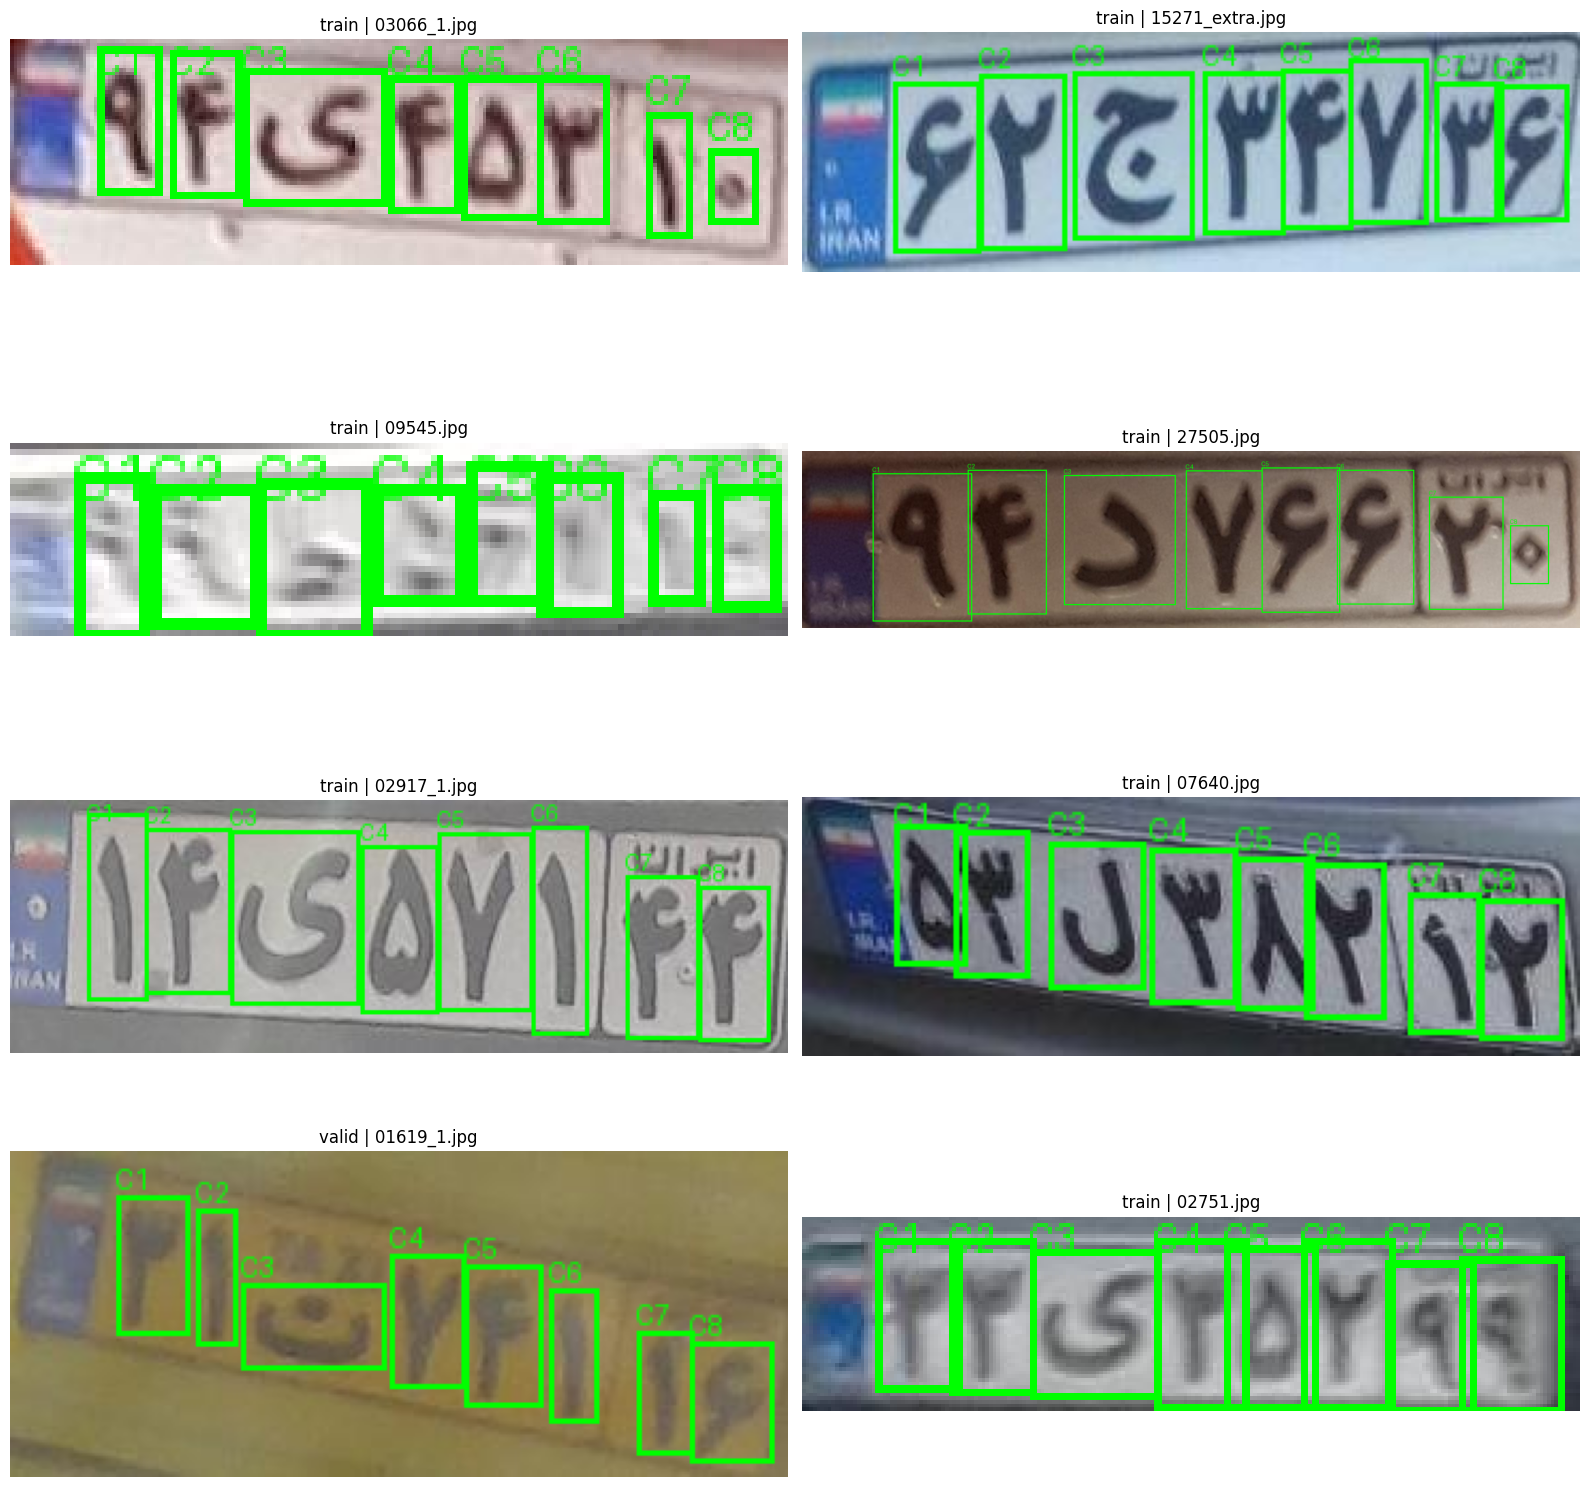

In [15]:
def draw_boxes_on_image(
    image: Image.Image,
    boxes: List[ValidCharacterBox],
    title: str = "",
) -> Image.Image:
    img = image.copy()
    draw = ImageDraw.Draw(img)

    for i, box in enumerate(boxes, start=1):
        color = "lime"
        draw.rectangle([box.xmin, box.ymin, box.xmax, box.ymax], outline=color, width=2)
        draw.text((box.xmin, max(0, box.ymin - 12)), f"C{i}", fill=color)

    return img


def visualize_valid_samples(
    samples: List[ValidSample],
    count: int,
    save_dir: Path,
    seed: int,
) -> None:
    rng = random.Random(seed)
    chosen = rng.sample(samples, k=min(count, len(samples)))

    cols = 2
    rows = math.ceil(len(chosen) / cols)

    plt.figure(figsize=(cols * 8, rows * 4))

    for idx, sample in enumerate(chosen):
        img = load_rgb_image(sample.image_path)
        vis = draw_boxes_on_image(img, sample.boxes_left_to_right)

        out_path = save_dir / f"{sample.split}_{idx:03d}_{sample.image_path.stem}.png"
        vis.save(out_path)

        plt.subplot(rows, cols, idx + 1)
        plt.imshow(vis)
        plt.title(f"{sample.split} | {sample.image_path.name}")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(SAVED_DIR / "plots" / "model2_annotation_preview.png", dpi=160)
    plt.show()


visualize_valid_samples(
    samples=all_valid_samples,
    count=CFG.preview_count,
    save_dir=SAVED_DIR / "preview_annotations",
    seed=CFG.seed,
)

In [16]:
def voc_box_to_yolo_line(
    box: ValidCharacterBox,
    image_width: int,
    image_height: int,
    class_id: int,
) -> str:
    """
    Pascal/VOC pixel bbox:
        xmin, ymin, xmax, ymax

    YOLO normalized:
        class_id x_center y_center width height
    """
    x_center = ((box.xmin + box.xmax) / 2.0) / image_width
    y_center = ((box.ymin + box.ymax) / 2.0) / image_height
    width = (box.xmax - box.xmin) / image_width
    height = (box.ymax - box.ymin) / image_height

    vals = [x_center, y_center, width, height]

    if any(v <= 0 or v > 1 for v in vals):
        raise ValueError(
            f"Invalid YOLO normalized bbox values: {vals}, "
            f"box={box}, image_size={(image_width, image_height)}"
        )

    return f"{class_id} {x_center:.8f} {y_center:.8f} {width:.8f} {height:.8f}"

In [17]:
def prepare_yolo_dataset_dirs() -> None:
    ensure_clean_dir(GENERATED_DATASET_DIR)

    YOLO_IMAGES_TRAIN_DIR.mkdir(parents=True, exist_ok=True)
    YOLO_IMAGES_VALID_DIR.mkdir(parents=True, exist_ok=True)
    YOLO_LABELS_TRAIN_DIR.mkdir(parents=True, exist_ok=True)
    YOLO_LABELS_VALID_DIR.mkdir(parents=True, exist_ok=True)


def copy_image_and_write_label(sample: ValidSample, cfg: Model2Config) -> Dict[str, Any]:
    if sample.split == "train":
        image_out_dir = YOLO_IMAGES_TRAIN_DIR
        label_out_dir = YOLO_LABELS_TRAIN_DIR
    elif sample.split == "valid":
        image_out_dir = YOLO_IMAGES_VALID_DIR
        label_out_dir = YOLO_LABELS_VALID_DIR
    else:
        raise ValueError(f"Unexpected split: {sample.split}")

    out_image_path = image_out_dir / sample.image_path.name
    out_label_path = label_out_dir / f"{sample.image_path.stem}.txt"

    shutil.copy2(sample.image_path, out_image_path)

    lines = [
        voc_box_to_yolo_line(
            box=box,
            image_width=sample.width,
            image_height=sample.height,
            class_id=cfg.yolo_class_id,
        )
        for box in sample.boxes_left_to_right
    ]

    if len(lines) != cfg.required_character_count:
        raise RuntimeError(
            f"Conversion sanity check failed for {sample.image_path}: "
            f"expected {cfg.required_character_count} lines, got {len(lines)}"
        )

    out_label_path.write_text("\n".join(lines) + "\n", encoding="utf-8")

    return {
        "split": sample.split,
        "source_image": str(sample.image_path),
        "source_xml": str(sample.xml_path),
        "yolo_image": str(out_image_path),
        "yolo_label": str(out_label_path),
        "num_boxes": len(lines),
        "width": sample.width,
        "height": sample.height,
    }


prepare_yolo_dataset_dirs()

conversion_rows = []

for sample in tqdm(all_valid_samples, desc="Generating YOLO dataset"):
    conversion_rows.append(copy_image_and_write_label(sample, CFG))

conversion_df = pd.DataFrame(conversion_rows)
conversion_log_path = SAVED_DIR / CFG.conversion_log_name
conversion_df.to_csv(conversion_log_path, index=False, encoding="utf-8-sig")

print("[OK] YOLO dataset generated.")
print("Conversion log:", conversion_log_path)

print("Train images:", len(list(YOLO_IMAGES_TRAIN_DIR.glob("*"))))
print("Train labels:", len(list(YOLO_LABELS_TRAIN_DIR.glob("*.txt"))))
print("Valid images:", len(list(YOLO_IMAGES_VALID_DIR.glob("*"))))
print("Valid labels:", len(list(YOLO_LABELS_VALID_DIR.glob("*.txt"))))

display(conversion_df.head())

Generating YOLO dataset:   0%|          | 0/32055 [00:00<?, ?it/s]

[OK] YOLO dataset generated.
Conversion log: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved_models/model_2_fixed/conversion_log.csv
Train images: 27070
Train labels: 27070
Valid images: 4985
Valid labels: 4985


,split,source_image,source_xml,yolo_image,yolo_label,num_boxes,width,height
0,train,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,/Users/sam/Desktop/aiolearn/My_projects/CLPR/S...,/Users/sam/Desktop/aiolearn/My_projects/CLPR/S...,8,176,158
1,train,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,/Users/sam/Desktop/aiolearn/My_projects/CLPR/S...,/Users/sam/Desktop/aiolearn/My_projects/CLPR/S...,8,580,317
2,train,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,/Users/sam/Desktop/aiolearn/My_projects/CLPR/S...,/Users/sam/Desktop/aiolearn/My_projects/CLPR/S...,8,584,277
3,train,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,/Users/sam/Desktop/aiolearn/My_projects/CLPR/S...,/Users/sam/Desktop/aiolearn/My_projects/CLPR/S...,8,548,246
4,train,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,/Users/sam/Desktop/aiolearn/My_projects/CLPR/S...,/Users/sam/Desktop/aiolearn/My_projects/CLPR/S...,8,579,196


In [18]:
def write_yolo_data_yaml(path: Path, cfg: Model2Config) -> None:
    """
    Write a minimal YOLO data.yaml.

    Use absolute paths to avoid confusion caused by notebook working directory.
    """
    yaml_text = f"""
path: {GENERATED_DATASET_DIR.as_posix()}
train: {YOLO_IMAGES_TRAIN_DIR.as_posix()}
val: {YOLO_IMAGES_VALID_DIR.as_posix()}

nc: 1
names:
  0: {cfg.yolo_class_name}
"""
    path.write_text(yaml_text, encoding="utf-8")


write_yolo_data_yaml(DATA_YAML_PATH, CFG)

print(DATA_YAML_PATH.read_text(encoding="utf-8"))


path: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved_models/model_2_fixed/yolo_dataset
train: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved_models/model_2_fixed/yolo_dataset/images/train
val: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved_models/model_2_fixed/yolo_dataset/images/valid

nc: 1
names:
  0: character



In [19]:
def serialize_config(cfg: Model2Config) -> Dict[str, Any]:
    data = asdict(cfg)

    for k, v in list(data.items()):
        if isinstance(v, Path):
            data[k] = str(v)
        elif isinstance(v, tuple):
            data[k] = list(v)

    data["resolved_paths"] = {
        "project_root": str(PROJECT_ROOT),
        "dataset_root": str(DATASET_ROOT),
        "train_dir": str(TRAIN_DIR),
        "valid_dir": str(VALID_DIR),
        "base_yolo_model_path": str(BASE_YOLO_MODEL_PATH),
        "saved_dir": str(SAVED_DIR),
        "generated_dataset_dir": str(GENERATED_DATASET_DIR),
        "data_yaml": str(DATA_YAML_PATH),
    }

    return data


safe_json_dump(serialize_config(CFG), SAVED_DIR / CFG.config_name)

print("[OK] Config saved:", SAVED_DIR / CFG.config_name)

[OK] Config saved: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved_models/model_2_fixed/config.json


In [20]:
def read_yolo_label_file(label_path: Path) -> List[List[float]]:
    rows = []
    for line in label_path.read_text(encoding="utf-8").strip().splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            raise ValueError(f"Invalid YOLO label line in {label_path}: {line}")

        class_id = int(parts[0])
        vals = [float(x) for x in parts[1:]]

        if class_id != CFG.yolo_class_id:
            raise ValueError(f"Unexpected class id in {label_path}: {class_id}")

        if any(v <= 0 or v > 1 for v in vals):
            raise ValueError(f"Invalid normalized bbox values in {label_path}: {vals}")

        rows.append([class_id] + vals)

    return rows


def sanity_check_yolo_labels(label_dir: Path, expected_count: int) -> None:
    label_files = sorted(label_dir.glob("*.txt"))
    if len(label_files) == 0:
        raise RuntimeError(f"No YOLO label files found in {label_dir}")

    bad_files = []

    for label_path in label_files:
        try:
            rows = read_yolo_label_file(label_path)
            if len(rows) != expected_count:
                bad_files.append((str(label_path), f"Expected {expected_count}, found {len(rows)}"))
        except Exception as exc:
            bad_files.append((str(label_path), repr(exc)))

    if bad_files:
        for item in bad_files[:20]:
            print(item)
        raise RuntimeError(f"YOLO label sanity check failed for {len(bad_files)} files.")

    print(f"[OK] All labels in {label_dir} passed sanity check.")


sanity_check_yolo_labels(YOLO_LABELS_TRAIN_DIR, CFG.required_character_count)
sanity_check_yolo_labels(YOLO_LABELS_VALID_DIR, CFG.required_character_count)

[OK] All labels in /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved_models/model_2_fixed/yolo_dataset/labels/train passed sanity check.
[OK] All labels in /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved_models/model_2_fixed/yolo_dataset/labels/valid passed sanity check.


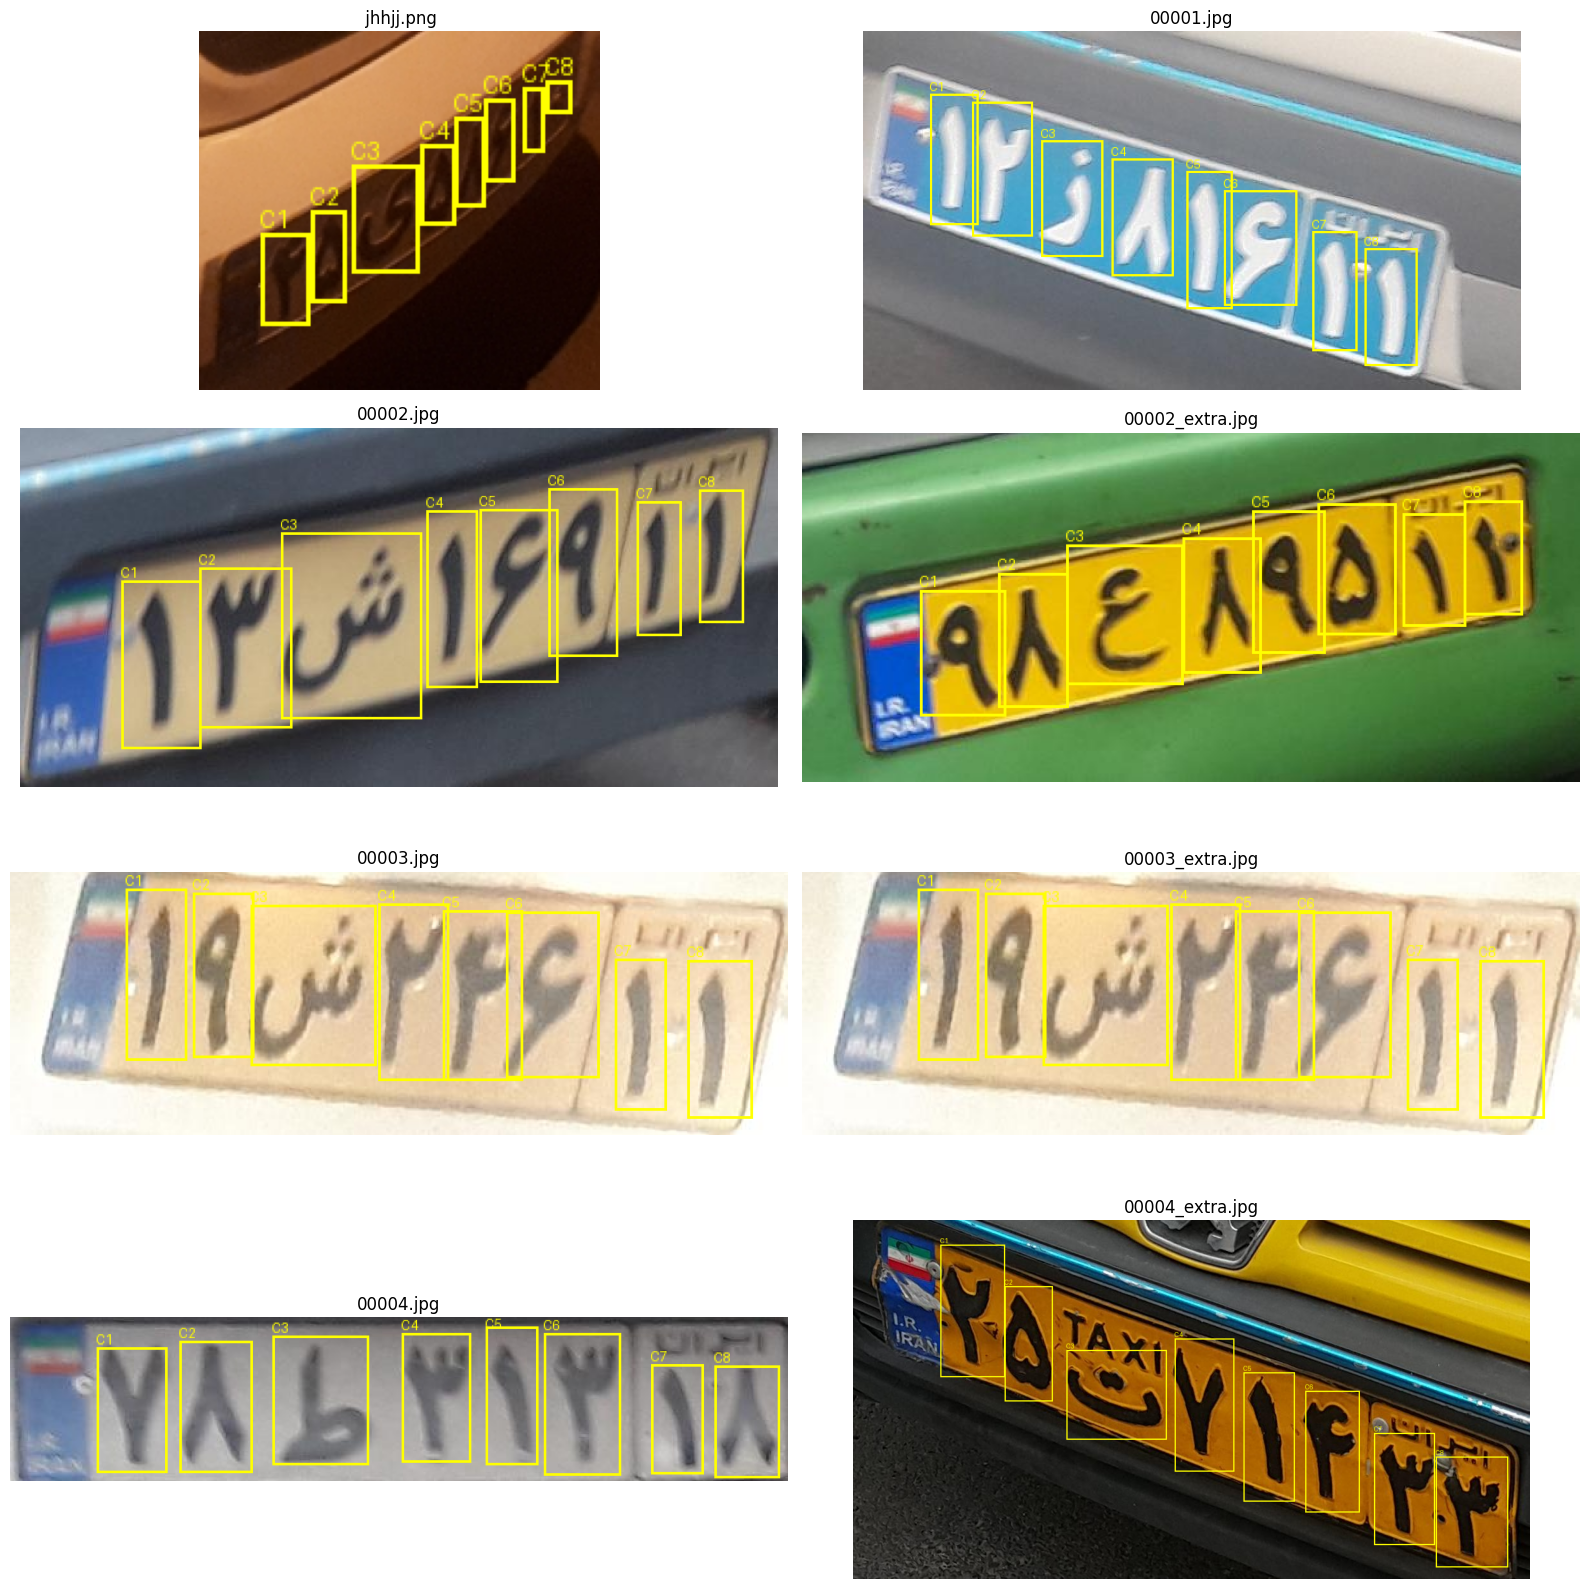

In [21]:
def yolo_to_voc(
    x_center: float,
    y_center: float,
    width: float,
    height: float,
    img_w: int,
    img_h: int,
) -> Tuple[int, int, int, int]:
    cx = x_center * img_w
    cy = y_center * img_h
    bw = width * img_w
    bh = height * img_h

    xmin = int(round(cx - bw / 2))
    ymin = int(round(cy - bh / 2))
    xmax = int(round(cx + bw / 2))
    ymax = int(round(cy + bh / 2))

    return xmin, ymin, xmax, ymax


def visualize_yolo_sample(image_path: Path, label_path: Path) -> Image.Image:
    img = load_rgb_image(image_path)
    img_w, img_h = img.size
    draw = ImageDraw.Draw(img)

    rows = read_yolo_label_file(label_path)

    rows = sorted(rows, key=lambda r: r[1])

    for i, row in enumerate(rows, start=1):
        _, x_center, y_center, bw, bh = row
        xmin, ymin, xmax, ymax = yolo_to_voc(x_center, y_center, bw, bh, img_w, img_h)
        draw.rectangle([xmin, ymin, xmax, ymax], outline="yellow", width=2)
        draw.text((xmin, max(0, ymin - 12)), f"C{i}", fill="yellow")

    return img


sample_label_files = sorted(YOLO_LABELS_TRAIN_DIR.glob("*.txt"))[:CFG.preview_count]

cols = 2
rows = math.ceil(len(sample_label_files) / cols)

plt.figure(figsize=(cols * 8, rows * 4))

for idx, label_path in enumerate(sample_label_files):
    image_candidates = list(YOLO_IMAGES_TRAIN_DIR.glob(label_path.stem + ".*"))
    if not image_candidates:
        continue

    image_path = image_candidates[0]
    vis = visualize_yolo_sample(image_path, label_path)

    plt.subplot(rows, cols, idx + 1)
    plt.imshow(vis)
    plt.title(image_path.name)
    plt.axis("off")

plt.tight_layout()
plt.savefig(SAVED_DIR / "plots" / "model2_yolo_conversion_preview.png", dpi=160)
plt.show()

## YOLO Training Note

The notebook requests MPS if available.

If the installed YOLO/Ultralytics backend does not support your MPS setup properly, this notebook should not silently pretend everything is fine.

- If MPS training fails, inspect the error.
- You may explicitly set `allow_yolo_cpu_fallback=True` in config if you accept CPU training.
- No CUDA-only `.cuda()` code is used.

In [22]:
print("Loading base YOLO model from:", BASE_YOLO_MODEL_PATH)

yolo_model = YOLO(str(BASE_YOLO_MODEL_PATH))

print("[OK] YOLO model loaded.")

Loading base YOLO model from: /Users/sam/Desktop/aiolearn/My_projects/CLPR/yolo models/yolo26l.pt
[OK] YOLO model loaded.


In [23]:
print_boxed("Starting YOLO training for Model 2")
print("Data YAML:", DATA_YAML_PATH)
print("Device:", YOLO_DEVICE)
print("Base model:", BASE_YOLO_MODEL_PATH)
print("Save project:", SAVED_DIR)

try:
    train_results = yolo_model.train(
        data=str(DATA_YAML_PATH),
        epochs=CFG.epochs,
        imgsz=CFG.imgsz,
        batch=CFG.batch,
        patience=CFG.patience,
        workers=CFG.workers,
        device=YOLO_DEVICE,
        project=str(SAVED_DIR),
        name="train_run",
        exist_ok=True,
        seed=CFG.seed,

        pretrained=True,
        single_cls=True,
        rect=False,
        cache=False,
        plots=True,
        val=True,

        optimizer=CFG.optimizer,
        lr0=CFG.lr0,
        lrf=CFG.lrf,
        weight_decay=CFG.weight_decay,
        warmup_epochs=CFG.warmup_epochs,
        warmup_momentum=CFG.warmup_momentum,
        warmup_bias_lr=CFG.warmup_bias_lr,
        cos_lr=CFG.cos_lr,

        box=CFG.box,
        cls=CFG.cls,
        dfl=CFG.dfl,

        close_mosaic=CFG.close_mosaic,

        hsv_h=CFG.hsv_h,
        hsv_s=CFG.hsv_s,
        hsv_v=CFG.hsv_v,
        degrees=CFG.degrees,
        translate=CFG.translate,
        scale=CFG.scale,
        shear=CFG.shear,
        perspective=CFG.perspective,
        flipud=CFG.flipud,
        fliplr=CFG.fliplr,
        mosaic=CFG.mosaic,
        mixup=CFG.mixup,
        copy_paste=CFG.copy_paste,
        erasing=CFG.erasing,

        verbose=True,
    )

    print("[OK] YOLO training finished.")

except Exception as exc:
    print("[ERROR] YOLO training failed.")
    print("Device requested:", YOLO_DEVICE)
    print("Error type:", type(exc).__name__)
    print("Error:", exc)

    if YOLO_DEVICE == "mps":
        print(
            "\n[IMPORTANT] MPS was requested. "
            "If your Ultralytics/PyTorch combination does not support this training path, "
            "do NOT silently switch to CPU. "
            "Set CFG.allow_yolo_cpu_fallback=True explicitly if you accept CPU training."
        )

    raise


Starting YOLO training for Model 2
Data YAML: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved_models/model_2_fixed/data.yaml
Device: mps
Base model: /Users/sam/Desktop/aiolearn/My_projects/CLPR/yolo models/yolo26l.pt
Save project: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved_models/model_2_fixed
New https://pypi.org/project/ultralytics/8.4.72 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.70 🚀 Python-3.10.19 torch-2.12.0 MPS (Apple M4 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=10.0, cache=False, cfg=None, classes=None, close_mosaic=0, cls=0.2, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved_models/model_2_fixed/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=2.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=250, erasing=0.0, ex

KeyboardInterrupt: 

In [24]:
@dataclass
class PredBox:
    xmin: float
    ymin: float
    xmax: float
    ymax: float
    conf: float

    @property
    def center_x(self) -> float:
        return (self.xmin + self.xmax) / 2.0

    @property
    def center_y(self) -> float:
        return (self.ymin + self.ymax) / 2.0

    @property
    def width(self) -> float:
        return self.xmax - self.xmin

    @property
    def height(self) -> float:
        return self.ymax - self.ymin

    @property
    def area(self) -> float:
        return max(0.0, self.width) * max(0.0, self.height)


def pred_iou(a: PredBox, b: PredBox) -> float:
    inter_x1 = max(a.xmin, b.xmin)
    inter_y1 = max(a.ymin, b.ymin)
    inter_x2 = min(a.xmax, b.xmax)
    inter_y2 = min(a.ymax, b.ymax)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    union = a.area + b.area - inter_area
    if union <= 0:
        return 0.0

    return inter_area / union


def nms_pred_boxes(boxes: List[PredBox], iou_threshold: float) -> List[PredBox]:
    boxes_sorted = sorted(boxes, key=lambda b: b.conf, reverse=True)
    kept: List[PredBox] = []

    for box in boxes_sorted:
        if all(pred_iou(box, kept_box) < iou_threshold for kept_box in kept):
            kept.append(box)

    return kept


def select_exact_8_boxes(
    boxes: List[PredBox],
    cfg: Model2Config,
) -> List[PredBox]:
    boxes = [b for b in boxes if b.conf >= cfg.exact8_conf_floor]
    boxes = nms_pred_boxes(boxes, iou_threshold=cfg.exact8_nms_iou)

    if len(boxes) > cfg.required_character_count:
        boxes = sorted(boxes, key=lambda b: b.conf, reverse=True)[:cfg.required_character_count]

    boxes = sorted(boxes, key=lambda b: (b.center_x, b.center_y))

    if len(boxes) < cfg.required_character_count:
        return boxes

    return boxes


def predict_plate_char_boxes_exact8(
    model: YOLO,
    image_path: Path,
    cfg: Model2Config,
) -> List[PredBox]:
    results = model.predict(
        source=str(image_path),
        imgsz=cfg.imgsz,
        conf=cfg.exact8_conf_floor,
        iou=cfg.inference_iou,
        max_det=cfg.max_det,
        device=YOLO_DEVICE,
        verbose=False,
    )

    result = results[0]
    pred_boxes: List[PredBox] = []

    if result.boxes is None or len(result.boxes) == 0:
        return []

    xyxy = result.boxes.xyxy.detach().cpu().numpy()
    confs = result.boxes.conf.detach().cpu().numpy()

    for coords, conf in zip(xyxy, confs):
        xmin, ymin, xmax, ymax = coords.tolist()
        pred_boxes.append(
            PredBox(
                xmin=float(xmin),
                ymin=float(ymin),
                xmax=float(xmax),
                ymax=float(ymax),
                conf=float(conf),
            )
        )

    return select_exact_8_boxes(pred_boxes, cfg)

In [25]:
def valid_box_to_pred_box(box: ValidCharacterBox) -> PredBox:
    return PredBox(
        xmin=float(box.xmin),
        ymin=float(box.ymin),
        xmax=float(box.xmax),
        ymax=float(box.ymax),
        conf=1.0,
    )


def evaluate_exact8_on_valid_samples(
    model_path: Path,
    samples: List[ValidSample],
    cfg: Model2Config,
    output_path: Path,
) -> pd.DataFrame:
    model = YOLO(str(model_path))

    rows = []

    for sample in tqdm(samples, desc="Exact-8 validation"):
        pred_boxes = predict_plate_char_boxes_exact8(
            model=model,
            image_path=sample.image_path,
            cfg=cfg,
        )

        gt_boxes = [valid_box_to_pred_box(box) for box in sample.boxes_left_to_right]

        exact_count = len(pred_boxes) == cfg.required_character_count

        ious = []
        if exact_count:
            for gt_box, pred_box in zip(gt_boxes, pred_boxes):
                ious.append(pred_iou(gt_box, pred_box))

        mean_iou = float(np.mean(ious)) if ious else 0.0
        min_iou = float(np.min(ious)) if ious else 0.0

        rows.append(
            {
                "image_path": str(sample.image_path),
                "xml_path": str(sample.xml_path),
                "pred_count": len(pred_boxes),
                "exact8": exact_count,
                "mean_iou_ordered": mean_iou,
                "min_iou_ordered": min_iou,
                "mean_conf": float(np.mean([b.conf for b in pred_boxes])) if pred_boxes else 0.0,
                "min_conf": float(np.min([b.conf for b in pred_boxes])) if pred_boxes else 0.0,
            }
        )

    df = pd.DataFrame(rows)
    df.to_csv(output_path, index=False, encoding="utf-8-sig")

    print_boxed("Exact-8 validation summary")
    print(f"Samples: {len(df):,}")
    print(f"Exact-8 rate: {df['exact8'].mean():.6f}")
    print(f"Mean ordered IoU: {df['mean_iou_ordered'].mean():.6f}")
    print(f"Min ordered IoU mean: {df['min_iou_ordered'].mean():.6f}")
    print("Report saved to:", output_path)

    return df


In [ ]:
best_model_path = SAVED_DIR / "train_run" / "weights" / "best.pt"

exact8_report_df = evaluate_exact8_on_valid_samples(
    model_path=best_model_path,
    samples=valid_valid_samples,
    cfg=CFG,
    output_path=SAVED_DIR / CFG.exact8_validation_report_name,
)

display(exact8_report_df.sort_values(
    ["exact8", "mean_iou_ordered", "min_conf"],
    ascending=[True, True, True],
).head(30))

Exact-8 validation:   0%|          | 0/4985 [00:00<?, ?it/s]

AttributeError: 'Model2Config' object has no attribute 'exact8_conf_floor'

In [28]:
TRAIN_RUN_DIR = SAVED_DIR / "train_run"
WEIGHTS_DIR = TRAIN_RUN_DIR / "weights"

MODEL2_BEST_PT = WEIGHTS_DIR / "best.pt"
MODEL2_LAST_PT = WEIGHTS_DIR / "last.pt"

if not MODEL2_BEST_PT.exists():
    raise FileNotFoundError(f"YOLO best.pt not found: {MODEL2_BEST_PT}")

if not MODEL2_LAST_PT.exists():
    print("[WARN] YOLO last.pt not found. Some YOLO versions may save differently:", MODEL2_LAST_PT)

print("Best weights:", MODEL2_BEST_PT)
print("Last weights:", MODEL2_LAST_PT)

Best weights: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved_models/model_2_fixed/train_run/weights/best.pt
Last weights: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved_models/model_2_fixed/train_run/weights/last.pt


In [29]:
best_yolo_model = YOLO(str(MODEL2_BEST_PT))

print_boxed("Running YOLO validation")

val_results = best_yolo_model.val(
    data=str(DATA_YAML_PATH),
    imgsz=CFG.imgsz,
    batch=CFG.batch,
    device=YOLO_DEVICE,
    workers=CFG.workers,
    conf=CFG.validation_conf,
    iou=CFG.inference_iou,
    verbose=True,
)

print("[OK] Validation finished.")

metrics_summary = {}

try:
    metrics_summary["box_map"] = float(val_results.box.map)
    metrics_summary["box_map50"] = float(val_results.box.map50)
    metrics_summary["box_map75"] = float(val_results.box.map75)
except Exception as exc:
    metrics_summary["warning"] = f"Could not extract mAP metrics: {repr(exc)}"

safe_json_dump(metrics_summary, SAVED_DIR / "validation_metrics.json")

print(metrics_summary)


Running YOLO validation
Ultralytics 8.4.70 🚀 Python-3.10.19 torch-2.12.0 MPS (Apple M4 Pro)
YOLO26l summary (fused): 190 layers, 24,746,511 parameters, 0 gradients, 86.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 39.4±31.0 MB/s, size: 6.2 KB)
val: Scanning /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved_models/model_2_fixed/yolo_dataset/labels/valid.cache... 4985 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4985/4985 337.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 416/416 4.9it/s 1:260.5sss
                   all       4985      39880      0.998      0.999      0.995      0.815
Speed: 0.2ms preprocess, 12.2ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /Users/sam/Desktop/aiolearn/My_projects/CLPR/runs/detect/val-16
[OK] Validation finished.
{'box_map': 0.8149583667927797, 'box_map50': 0.9949186873386251, 'box_map75': 0.9403042906623771}


In [30]:
@dataclass
class DetectedCharacter:
    slot: int
    xmin: int
    ymin: int
    xmax: int
    ymax: int
    center_x: float
    center_y: float
    width: int
    height: int
    confidence: float


def clamp_int(v: int, lo: int, hi: int) -> int:
    return max(lo, min(hi, v))


def crop_character_from_plate(
    plate_img: Image.Image,
    det: DetectedCharacter,
    padding_px: int,
) -> Image.Image:
    w, h = plate_img.size

    xmin = clamp_int(det.xmin - padding_px, 0, w - 1)
    ymin = clamp_int(det.ymin - padding_px, 0, h - 1)
    xmax = clamp_int(det.xmax + padding_px, 1, w)
    ymax = clamp_int(det.ymax + padding_px, 1, h)

    if xmax <= xmin or ymax <= ymin:
        raise ValueError(f"Invalid crop after padding/clamp: {(xmin, ymin, xmax, ymax)}")

    return plate_img.crop((xmin, ymin, xmax, ymax))


def detections_from_yolo_result(
    result: Any,
    image_width: int,
    image_height: int,
    cfg: Model2Config,
) -> List[DetectedCharacter]:
    boxes = result.boxes

    detections: List[DetectedCharacter] = []

    if boxes is None or len(boxes) == 0:
        return detections

    xyxy = boxes.xyxy.detach().cpu().numpy()
    confs = boxes.conf.detach().cpu().numpy()

    for i in range(len(xyxy)):
        x1, y1, x2, y2 = xyxy[i]
        conf = float(confs[i])

        xmin = int(round(x1))
        ymin = int(round(y1))
        xmax = int(round(x2))
        ymax = int(round(y2))

        xmin = clamp_int(xmin, 0, image_width - 1)
        ymin = clamp_int(ymin, 0, image_height - 1)
        xmax = clamp_int(xmax, 1, image_width)
        ymax = clamp_int(ymax, 1, image_height)

        if xmax <= xmin or ymax <= ymin:
            continue

        detections.append(
            DetectedCharacter(
                slot=-1,
                xmin=xmin,
                ymin=ymin,
                xmax=xmax,
                ymax=ymax,
                center_x=(xmin + xmax) / 2.0,
                center_y=(ymin + ymax) / 2.0,
                width=xmax - xmin,
                height=ymax - ymin,
                confidence=conf,
            )
        )

    detections = sorted(detections, key=lambda d: (d.center_x, d.center_y))

    for idx, det in enumerate(detections, start=1):
        det.slot = idx

    return detections


def run_model2_on_plate_crop(
    image_path: Path,
    model: YOLO,
    cfg: Model2Config,
    device: str,
) -> Dict[str, Any]:
    if not image_path.exists():
        raise FileNotFoundError(f"Plate crop image does not exist: {image_path}")

    plate_img = load_rgb_image(image_path)
    image_width, image_height = plate_img.size

    results = model.predict(
        source=str(image_path),
        imgsz=cfg.imgsz,
        conf=cfg.inference_conf,
        iou=cfg.inference_iou,
        max_det=cfg.max_det,
        device=device,
        verbose=False,
    )

    if len(results) != 1:
        raise RuntimeError(f"Expected exactly one result for one input image, got {len(results)}")

    detections = detections_from_yolo_result(
        result=results[0],
        image_width=image_width,
        image_height=image_height,
        cfg=cfg,
    )

    accepted = len(detections) == cfg.required_character_count
    rejection_reason = None

    if not accepted:
        rejection_reason = (
            f"Model 2 rejected plate: expected exactly {cfg.required_character_count} "
            f"characters, detected {len(detections)}"
        )

    crops: List[Image.Image] = []
    if accepted:
        for det in detections:
            crops.append(
                crop_character_from_plate(
                    plate_img=plate_img,
                    det=det,
                    padding_px=cfg.crop_padding_px,
                )
            )

    return {
        "accepted": accepted,
        "rejection_reason": rejection_reason,
        "plate_image": plate_img,
        "detections": detections,
        "crops": crops,
        "raw_result": results[0],
    }

In [31]:
def visualize_model2_inference(result: Dict[str, Any], title: str = "Model 2 Inference") -> None:
    plate_img: Image.Image = result["plate_image"]
    detections: List[DetectedCharacter] = result["detections"]
    crops: List[Image.Image] = result["crops"]

    vis = plate_img.copy()
    draw = ImageDraw.Draw(vis)

    for det in detections:
        color = "lime" if result["accepted"] else "red"
        draw.rectangle([det.xmin, det.ymin, det.xmax, det.ymax], outline=color, width=2)
        draw.text(
            (det.xmin, max(0, det.ymin - 14)),
            f"C{det.slot} {det.confidence:.2f}",
            fill=color,
        )

    plt.figure(figsize=(12, 4))
    plt.imshow(vis)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    if not result["accepted"]:
        print("[REJECTED]", result["rejection_reason"])
        return

    cols = 8
    plt.figure(figsize=(cols * 2, 3))

    for i, crop in enumerate(crops, start=1):
        plt.subplot(1, cols, i)
        plt.imshow(crop)
        plt.title(f"C{i}")
        plt.axis("off")

    plt.suptitle("Ordered Character Crops C1-C8", fontsize=14)
    plt.tight_layout()
    plt.show()


def print_detection_metadata(detections: List[DetectedCharacter]) -> None:
    rows = []
    for det in detections:
        rows.append({
            "slot": f"C{det.slot}",
            "xmin": det.xmin,
            "ymin": det.ymin,
            "xmax": det.xmax,
            "ymax": det.ymax,
            "center_x": det.center_x,
            "center_y": det.center_y,
            "width": det.width,
            "height": det.height,
            "confidence": det.confidence,
        })

    df = pd.DataFrame(rows)
    display(df)

Sample plate crop: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Datasets/DS_model_2/valid/04083_1.jpg


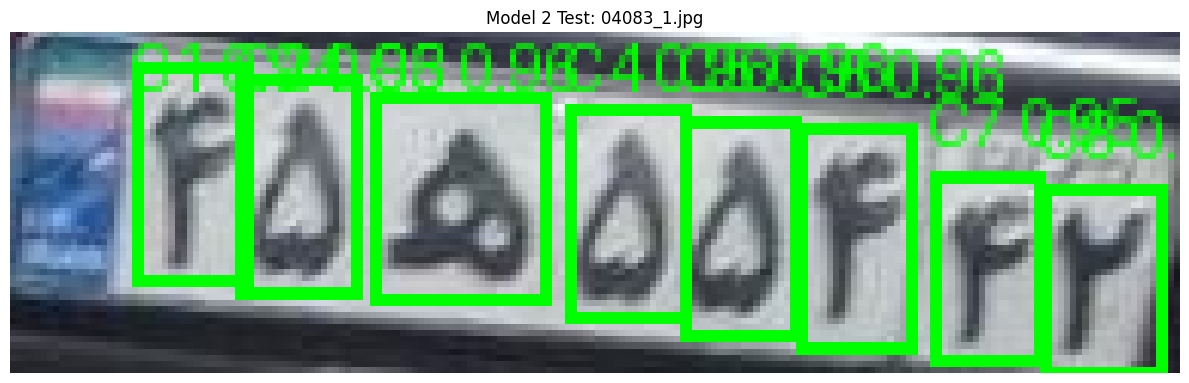

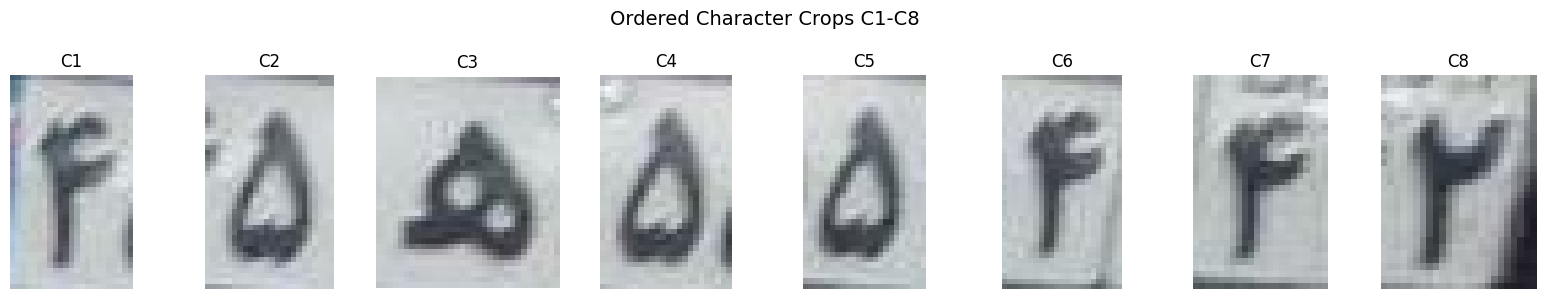

,slot,xmin,ymin,xmax,ymax,center_x,center_y,width,height,confidence
0,C1,20,5,39,41,29.5,23.0,19,36,0.943988
1,C2,37,7,57,43,47.0,25.0,20,36,0.947782
2,C3,59,10,88,44,73.5,27.0,29,34,0.961826
3,C4,91,12,111,47,101.0,29.5,20,35,0.957204
4,C5,110,14,129,50,119.5,32.0,19,36,0.956499
5,C6,129,15,148,52,138.5,33.5,19,37,0.958270
6,C7,151,23,169,54,160.0,38.5,18,31,0.949707
7,C8,169,25,189,56,179.0,40.5,20,31,0.955530


[OK] Plate accepted with exactly 8 ordered character detections.


In [32]:
sample = random.Random(CFG.seed).choice(valid_valid_samples)

print("Sample plate crop:", sample.image_path)

result = run_model2_on_plate_crop(
    image_path=sample.image_path,
    model=best_yolo_model,
    cfg=CFG,
    device=YOLO_DEVICE,
)

visualize_model2_inference(result, title=f"Model 2 Test: {sample.image_path.name}")
print_detection_metadata(result["detections"])

if result["accepted"]:
    print("[OK] Plate accepted with exactly 8 ordered character detections.")
else:
    print("[WARN] Plate rejected.")

In [33]:
def evaluate_exact8_rate(
    samples: List[ValidSample],
    model: YOLO,
    cfg: Model2Config,
    device: str,
    limit: Optional[int] = None,
) -> pd.DataFrame:
    rows = []
    eval_samples = samples if limit is None else samples[:limit]

    for sample in tqdm(eval_samples, desc="Evaluating exact-8 validation rate"):
        try:
            result = run_model2_on_plate_crop(
                image_path=sample.image_path,
                model=model,
                cfg=cfg,
                device=device,
            )

            detections = result["detections"]

            mean_conf = float(np.mean([d.confidence for d in detections])) if detections else 0.0

            rows.append({
                "image_path": str(sample.image_path),
                "accepted": result["accepted"],
                "detected_count": len(detections),
                "mean_confidence": mean_conf,
                "rejection_reason": result["rejection_reason"],
            })

        except Exception as exc:
            rows.append({
                "image_path": str(sample.image_path),
                "accepted": False,
                "detected_count": -1,
                "mean_confidence": 0.0,
                "rejection_reason": repr(exc),
            })

    return pd.DataFrame(rows)


exact8_df = evaluate_exact8_rate(
    samples=valid_valid_samples,
    model=best_yolo_model,
    cfg=CFG,
    device=YOLO_DEVICE,
    limit=None,
)

exact8_path = SAVED_DIR / "validation_exact8_rate.csv"
exact8_df.to_csv(exact8_path, index=False, encoding="utf-8-sig")

display(exact8_df.head())

exact8_rate = exact8_df["accepted"].mean()
print(f"Exact-8 acceptance rate on validation: {exact8_rate:.4f}")
print("Saved to:", exact8_path)

Evaluating exact-8 validation rate:   0%|          | 0/4985 [00:00<?, ?it/s]

,image_path,accepted,detected_count,mean_confidence,rejection_reason
0,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,True,8,0.926407,None
1,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,True,8,0.929285,None
2,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,True,8,0.881756,None
3,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,True,8,0.908227,None
4,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,True,8,0.945811,None


Exact-8 acceptance rate on validation: 0.9741
Saved to: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved_models/model_2_fixed/validation_exact8_rate.csv


In [34]:
def save_model2_inference_visual(
    result: Dict[str, Any],
    out_path: Path,
) -> None:
    plate_img: Image.Image = result["plate_image"]
    detections: List[DetectedCharacter] = result["detections"]

    vis = plate_img.copy()
    draw = ImageDraw.Draw(vis)

    for det in detections:
        color = "lime" if result["accepted"] else "red"
        draw.rectangle([det.xmin, det.ymin, det.xmax, det.ymax], outline=color, width=2)
        draw.text(
            (det.xmin, max(0, det.ymin - 14)),
            f"C{det.slot} {det.confidence:.2f}",
            fill=color,
        )

    vis.save(out_path)


example_dir = SAVED_DIR / "inference_examples"
example_dir.mkdir(parents=True, exist_ok=True)

rng = random.Random(CFG.seed)
example_samples = rng.sample(valid_valid_samples, k=min(10, len(valid_valid_samples)))

for i, sample in enumerate(example_samples):
    result = run_model2_on_plate_crop(
        image_path=sample.image_path,
        model=best_yolo_model,
        cfg=CFG,
        device=YOLO_DEVICE,
    )

    out_path = example_dir / f"example_{i:03d}_{sample.image_path.stem}.png"
    save_model2_inference_visual(result, out_path)

print("[OK] Saved example prediction visualizations to:", example_dir)

[OK] Saved example prediction visualizations to: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved_models/model_2_fixed/inference_examples


In [35]:
input_path_str = input("Enter path to a cropped plate image: ").strip()

try:
    input_path = Path(input_path_str).expanduser().resolve()

    if not MODEL2_BEST_PT.exists():
        raise FileNotFoundError(f"Trained Model 2 best.pt not found: {MODEL2_BEST_PT}")

    inference_yolo_model = YOLO(str(MODEL2_BEST_PT))

    inference_result = run_model2_on_plate_crop(
        image_path=input_path,
        model=inference_yolo_model,
        cfg=CFG,
        device=YOLO_DEVICE,
    )

    print_boxed("Model 2 Result")
    print("Input:", input_path)
    print("Accepted:", inference_result["accepted"])

    if not inference_result["accepted"]:
        print("Rejection reason:", inference_result["rejection_reason"])

    visualize_model2_inference(
        inference_result,
        title=f"Model 2 Inference: {input_path.name}",
    )

    print_boxed("Detection Metadata")
    print_detection_metadata(inference_result["detections"])

    if inference_result["accepted"]:
        save_crops = input("Save ordered C1-C8 crops? [y/N]: ").strip().lower() == "y"

        if save_crops:
            out_dir = SAVED_DIR / "manual_inference_crops" / input_path.stem
            out_dir.mkdir(parents=True, exist_ok=True)

            for i, crop in enumerate(inference_result["crops"], start=1):
                crop_path = out_dir / f"C{i}.png"
                crop.save(crop_path)

            print("Saved crops to:", out_dir)

except Exception as exc:
    print("[ERROR] Model 2 inference failed.")
    print(type(exc).__name__ + ":", exc)

[ERROR] Model 2 inference failed.
IsADirectoryError: [Errno 21] Is a directory: '/Users/sam/Desktop/aiolearn/My_projects/CLPR'


In [37]:
def voc_iou_tuple(a: Tuple[int, int, int, int], b: Tuple[int, int, int, int]) -> float:
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    iw = max(0, ix2 - ix1)
    ih = max(0, iy2 - iy1)
    inter = iw * ih

    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)

    union = area_a + area_b - inter
    if union <= 0:
        return 0.0

    return inter / union


def evaluate_ordered_slot_iou(
    samples: List[ValidSample],
    model: YOLO,
    cfg: Model2Config,
    device: str,
    iou_threshold: float = 0.75,
) -> pd.DataFrame:
    rows = []

    for sample in tqdm(samples, desc="Evaluating ordered C1-C8 IoU"):
        try:
            result = run_model2_on_plate_crop(
                image_path=sample.image_path,
                model=model,
                cfg=cfg,
                device=device,
            )

            detections = result["detections"]
            exact8 = len(detections) == cfg.required_character_count

            slot_ious = []
            if exact8:
                for gt_box, det in zip(sample.boxes_left_to_right, detections):
                    gt_tuple = (gt_box.xmin, gt_box.ymin, gt_box.xmax, gt_box.ymax)
                    pred_tuple = (det.xmin, det.ymin, det.xmax, det.ymax)
                    slot_ious.append(voc_iou_tuple(gt_tuple, pred_tuple))

            mean_iou = float(np.mean(slot_ious)) if slot_ious else 0.0
            min_iou = float(np.min(slot_ious)) if slot_ious else 0.0
            all_slots_pass = exact8 and all(iou >= iou_threshold for iou in slot_ious)

            rows.append({
                "image_path": str(sample.image_path),
                "exact8": exact8,
                "detected_count": len(detections),
                "mean_slot_iou": mean_iou,
                "min_slot_iou": min_iou,
                "all_slots_iou_pass": all_slots_pass,
                "iou_threshold": iou_threshold,
            })

        except Exception as exc:
            rows.append({
                "image_path": str(sample.image_path),
                "exact8": False,
                "detected_count": -1,
                "mean_slot_iou": 0.0,
                "min_slot_iou": 0.0,
                "all_slots_iou_pass": False,
                "iou_threshold": iou_threshold,
                "error": repr(exc),
            })

    return pd.DataFrame(rows)


slot_iou_df = evaluate_ordered_slot_iou(
    samples=valid_valid_samples,
    model=best_yolo_model,
    cfg=CFG,
    device=YOLO_DEVICE,
    iou_threshold=0.75,
)

slot_iou_path = SAVED_DIR / "validation_ordered_slot_iou.csv"
slot_iou_df.to_csv(slot_iou_path, index=False, encoding="utf-8-sig")

display(slot_iou_df.head())

print("Exact-8 rate:", slot_iou_df["exact8"].mean())
print("All C1-C8 IoU pass rate:", slot_iou_df["all_slots_iou_pass"].mean())
print("Mean slot IoU:", slot_iou_df["mean_slot_iou"].mean())
print("Saved to:", slot_iou_path)

Evaluating ordered C1-C8 IoU:   0%|          | 0/4985 [00:00<?, ?it/s]

,image_path,exact8,detected_count,mean_slot_iou,min_slot_iou,all_slots_iou_pass,iou_threshold
0,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,True,8,0.910208,0.872060,True,0.75
1,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,True,8,0.874178,0.830488,True,0.75
2,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,True,8,0.875101,0.726496,False,0.75
3,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,True,8,0.930356,0.743961,False,0.75
4,/Users/sam/Desktop/aiolearn/My_projects/CLPR/D...,True,8,0.892316,0.775862,True,0.75


Exact-8 rate: 0.974122367101304
All C1-C8 IoU pass rate: 0.8756268806419257
Mean slot IoU: 0.903717046987392
Saved to: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved_models/model_2_fixed/validation_ordered_slot_iou.csv
